In [1]:
import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import NETWORK_TYPE

filename = "5G_data_2023.mat"

# Series of random seeds for reproducability
random_seeds = np.loadtxt('../data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename, NETWORK_TYPE._5G)

# # Drop unused columns to save space
matrix_cols_to_drop = ['toa_pps', 'toa_cir', 'toa_cov', 'campaign_id']
df['measurements_matrix'] = df['measurements_matrix'].apply(
    lambda x: x.drop(columns=matrix_cols_to_drop)
)

print(f"Loaded df of size {df.shape}")

df.info

Loaded dataframe from .h5 file: /Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/data/dataframe_cache/5G_data_2023.h5
Loaded df of size (33537, 4)


<bound method DataFrame.info of              lat        lng  \
0      41.898338  12.429556   
1      41.898337  12.429557   
2      41.898336  12.429557   
3      41.898335  12.429556   
4      41.898334  12.429555   
...          ...        ...   
33532  41.898398  12.429511   
33533  41.898396  12.429512   
33534  41.898388  12.429512   
33535  41.898383  12.429513   
33536  41.898380  12.429514   

                                     measurements_matrix  campaign_id  
0           pci  beam_index  nr_arfcn  operator_id   ...            1  
1           pci  beam_index  nr_arfcn  operator_id   ...            1  
2           pci  beam_index  nr_arfcn  operator_id   ...            1  
3           pci  beam_index  nr_arfcn  operator_id   ...            1  
4           pci  beam_index  nr_arfcn  operator_id   ...            1  
...                                                  ...          ...  
33532       pci  beam_index  nr_arfcn  operator_id   ...           79  
33533       pci  be

In [2]:
import pandas as pd


def count_frequencies(df: pd.DataFrame) -> dict:
    return {name: dict(group['beam_index'].value_counts()) for name, group in df.groupby('operator_id')}


df['counts'] = df['measurements_matrix'].apply(count_frequencies)

agg = {}
# Iterate through each row's counts
for _, row in df.iterrows():
    counts_dict = row['counts']

    # For each operator in the counts dictionary
    for operator_id, nr_arfcn_counts in counts_dict.items():
        # Initialize the operator in the agg dict if it doesn't exist
        if operator_id not in agg:
            agg[operator_id] = {}

        # For each nr_arfcn and its count
        for nr_arfcn, count in nr_arfcn_counts.items():
            # Convert numpy.int64 to regular int if needed
            count_value = int(count) if hasattr(count, 'item') else count

            # Add to existing count or initialize
            if nr_arfcn in agg[operator_id]:
                agg[operator_id][nr_arfcn] += count_value
            else:
                agg[operator_id][nr_arfcn] = count_value

agg

{1: {0: 216244},
 10: {3: 532859,
  6: 252767,
  1: 223309,
  2: 258557,
  4: 272777,
  5: 227100,
  0: 259632,
  7: 265627},
 50: {2: 405040,
  0: 100245,
  1: 93162,
  3: 90788,
  7: 118499,
  4: 94156,
  5: 79324,
  6: 91975},
 88: {3: 501461, 1: 229969, 2: 229659, 5: 242362, 0: 243632, 6: 251738}}

In [3]:


aggregated_df = pd.DataFrame(agg)

print(aggregated_df)

         1       10      50        88
0  216244.0  259632  100245  243632.0
3       NaN  532859   90788  501461.0
6       NaN  252767   91975  251738.0
1       NaN  223309   93162  229969.0
2       NaN  258557  405040  229659.0
4       NaN  272777   94156       NaN
5       NaN  227100   79324  242362.0
7       NaN  265627  118499       NaN


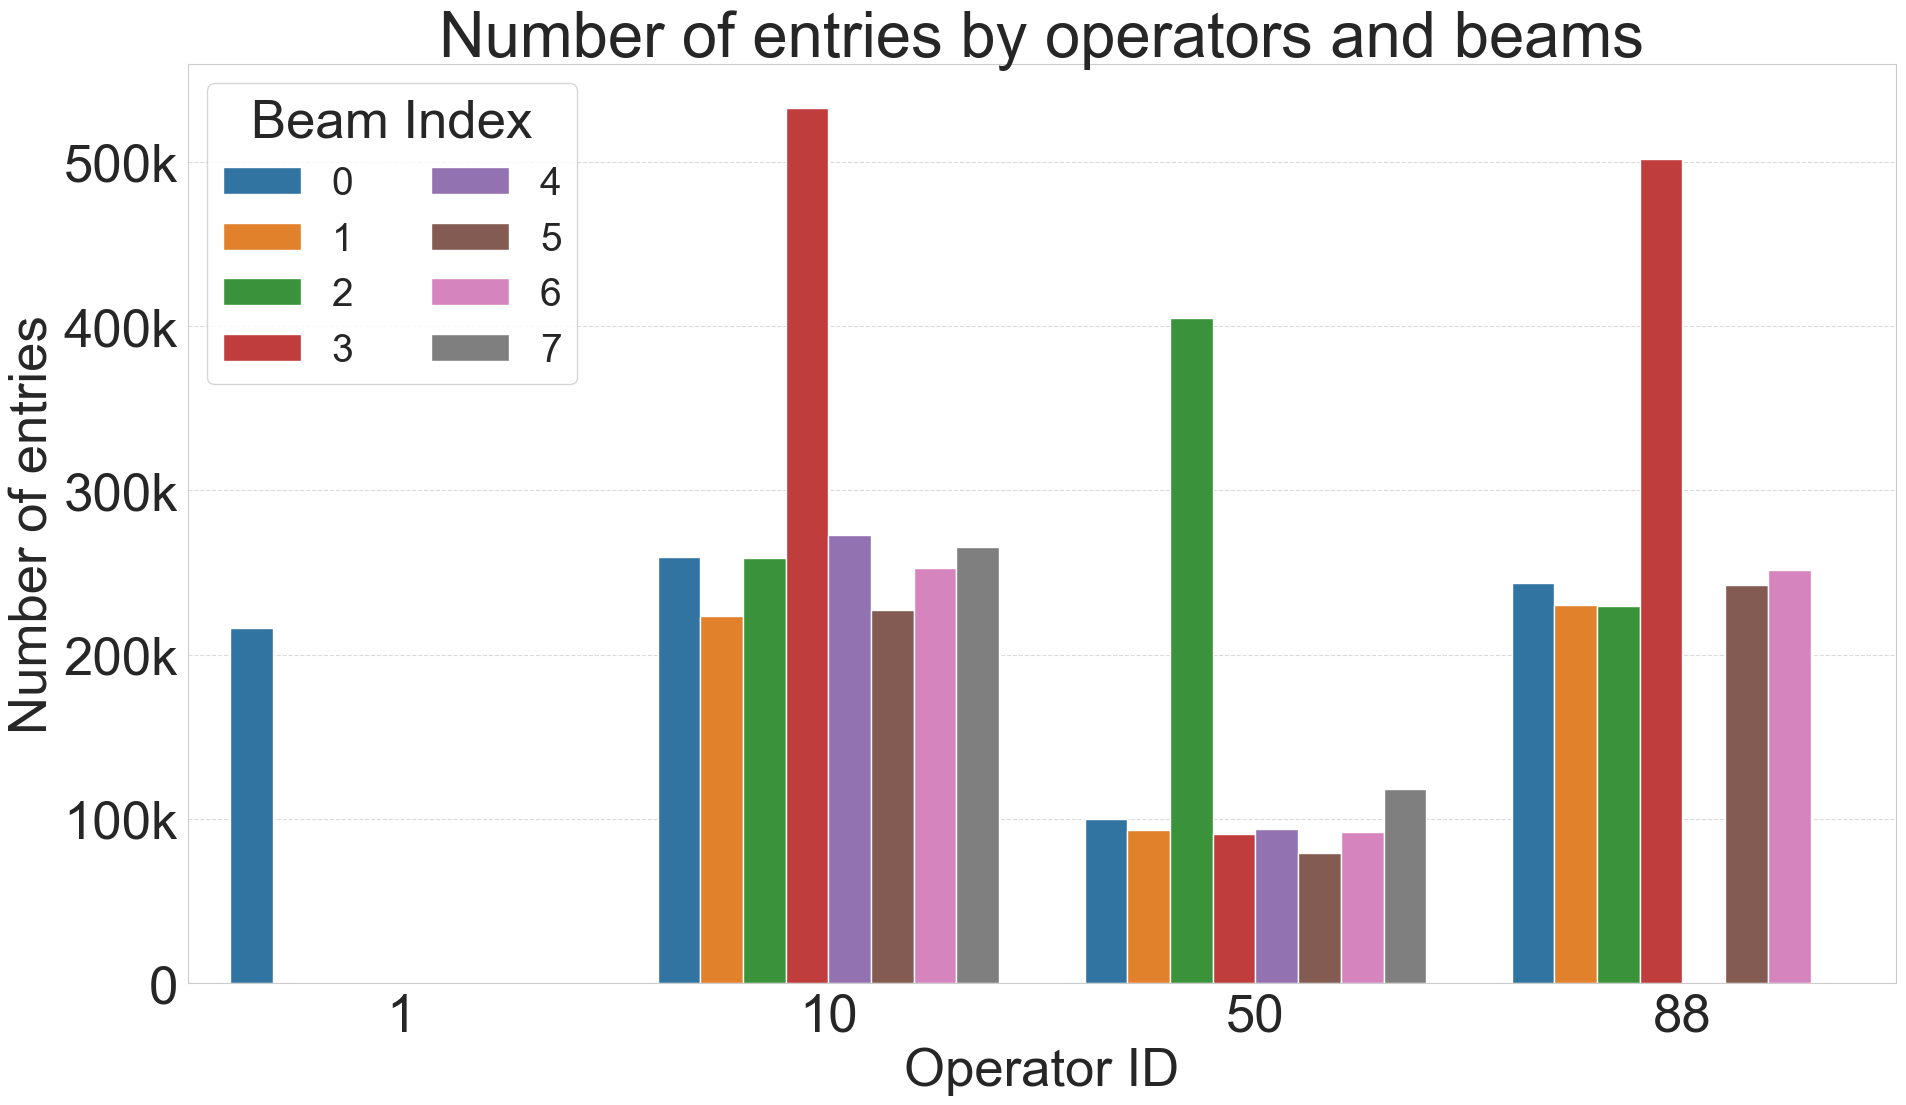

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams.update(
    {
        "font.size": 38,  # Default text size
    }
)

# Make a copy of the dataframe and reset the index
df_plot = aggregated_df.copy()
df_plot = df_plot.reset_index()
df_plot.columns = ['beam_index'] + list(aggregated_df.columns)

# Melt the DataFrame to long format
df_melted = pd.melt(df_plot, id_vars=['beam_index'],
                    value_vars=list(aggregated_df.columns),
                    var_name='operator_id', value_name='value')

# Drop rows with NaN values
df_melted = df_melted.dropna()

# Create the plot
plt.figure(figsize=(20, 12))
custom_palette = sns.color_palette("tab10", n_colors=8)  # Adjust n_colors as needed

# Create the grouped bar plot
# x-axis is operator_id, hue (grouping) is beam_index
ax = sns.barplot(
    x='operator_id',
    y='value',
    hue='beam_index',
    data=df_melted,
    errorbar=None,
    palette=custom_palette,
)

# Customize the plot
plt.title('Number of entries by operators and beams')
plt.xlabel('Operator ID')
plt.ylabel('Number of entries')

# Format y-axis to display large numbers better
from matplotlib.ticker import FuncFormatter


def format_thousands(x, pos):
    if x >= 1000:
        return f'{x / 1000:.0f}k'
    else:
        return f'{x:.0f}'


plt.gca().yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Improve legend
#plt.legend(title='Beam Index', loc='upper left', fontsize='32')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Beam Index', loc='upper left', fontsize='28', ncol=2)

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout to ensure everything fits
plt.tight_layout()

# Show the plot
plt.show()


In [33]:
import pandas as pd

# Assuming df_melted is your DataFrame
print(df_melted['beam_index'].unique())

# Group by 'operator_id' and 'beam_index', then sum the 'value'
grouped = df_melted.groupby(['operator_id', 'beam_index'])['value'].sum().reset_index()

# For each 'operator_id', find the 'beam_index' with the maximum 'value'
max_beams = grouped.loc[grouped.groupby('operator_id')['value'].idxmax()]

# Calculate the total 'value' for each 'operator_id' and convert it to a DataFrame
totals = df_melted.groupby('operator_id')['value'].sum().reset_index()

# Rename the 'value' column to 'total'
totals.rename(columns={'value': 'total'}, inplace=True)

# Merge the totals with the max beams
res = pd.merge(totals, max_beams, on='operator_id', how='left')

res['percentage'] = res['value'] / res['total'] * 100

res

[0 3 6 1 2 4 5 7]


,operator_id,total,beam_index,value,percentage
0,1,216244.0,0,216244.0,100.000000
1,10,2292628.0,3,532859.0,23.242279
2,50,1073189.0,2,405040.0,37.741721
3,88,1698821.0,3,501461.0,29.518178


In [26]:
totals

operator_id
1      216244.0
10    2292628.0
50    1073189.0
88    1698821.0
Name: value, dtype: float64